## Introduction

### Automatic traffic sign recognition is a key problem in the field of computer vision, with essential applications in driver assistance systems and autonomous vehicles
### In this project, which is more focused on statistical analysis, I used a road sign detection dataset collected by myself and a colleague with Google Maps, to answer the following questions:

### Question (1): Are the data distributions (bounding box positions, bounding box size, zoom level, etc., excluding images) consistent with a multimodal distribution? Are there any anomalous entries?

### Question (2): Do the samples from the two data collectors (excluding images) follow similar distributions?

### Question (3): Is there a relationship between the label and the size of the bounding box?

### Question (4): Is it possible to classify the contents of the bounding boxes based on their histograms?

### Question (5): Does the classifier's performance vary significantly across different acquisition locations?

### The first question aims to model the distribution of part of the data. In particular, we have chosen to model the positions of the centers of the bounding boxes using a multimodal distribution. This allowed us to identify outliers.

### The second question seeks to investigate the data acquisition methods of the two students, in order to verify whether they tend to collect data in a similar way.

### The fourth question explores the possibility of accurately predicting the class of a traffic sign based on a reduced feature set: a histogram.

### The fifth question is designed to verify whether the model is overfitting to certain acquisition areas, by checking the correlation between associated cluster and correct predictions, using a statistical test for categorical variables.

## Data
### The data was collected from Google Maps using a tool I developed, which allows the user to frame a specific screen area and capture its contents, automatically storing metadata about the acquisition coordinates. Labels were created using the "labelimg" tool.

### Each entry in the dataset includes:

#### -An image, showing N traffic signs

#### -N bounding boxes (in xyxy format)

#### -N labels

#### -Acquisition coordinates from Google Maps: latitude, longitude, heading, tilt, zoom

#### -Data acquirer (boolean)

# Importing libraries, loading data and some initializations

In [1]:
import numpy
import pandas as pd
from sklearn.mixture import GaussianMixture
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image


from hyppo.ksample import Energy
from scipy.stats import chi2_contingency


from statsmodels.formula.api import mnlogit

import torch
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger
#from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.callbacks import LearningRateMonitor
from pytorch_lightning.callbacks import RichProgressBar

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.model_selection import KFold
from torch.utils.data import Subset


torch.set_float32_matmul_precision('medium')


#set seeds to 47
numpy.random.seed(47)
random.seed(47)
torch.manual_seed(47)



dataset_path = "F:/Università/x.Magistrale/Primo_Anno\Machine Learning/Progetto/Datasets/GMAPSCT/dataset"

### Metadata dataframe (for acquirer and acquisition coordinates)

In [2]:
metadata_df = pd.read_csv(os.path.join(dataset_path, "coordinates.csv"))

metadata_df["acquirer"] = list(map(lambda x: 0 if x <= 2345 else 1, metadata_df["id"]))
metadata_df["acquirer"] = metadata_df["acquirer"].astype("category")

metadata_df.head()

,id,longitude,latitude,zoom,heading,tilt,width,height,acquirer
0,0,15.097390,37.505433,21.2,305.80,88.12,200.0,200.0,0
1,1,15.097253,37.505288,75.0,61.11,77.84,200.0,200.0,0
2,2,15.097253,37.505288,48.4,268.37,79.56,200.0,200.0,0
3,3,15.097192,37.505222,33.3,279.81,84.90,200.0,200.0,0
4,4,15.096769,37.504804,75.0,286.23,76.79,200.0,200.0,0


### Bounding boxes dataframe (for bounding boxes coordinates and labels)

In [3]:
bboxes_df = pd.read_csv(os.path.join(dataset_path, "labels.csv"))


#normalize the coordinates using the image size contained in the metadata_df

#join with metadata_df to get the image size for each image
bboxes_df = bboxes_df.merge(metadata_df[["id", "width", "height"]], on="id", how="left")

#normalize the coordinates
bboxes_df["xmin"] = bboxes_df["xmin"] / bboxes_df["width"]
bboxes_df["ymin"] = bboxes_df["ymin"] / bboxes_df["height"]
bboxes_df["xmax"] = bboxes_df["xmax"] / bboxes_df["width"]
bboxes_df["ymax"] = bboxes_df["ymax"] / bboxes_df["height"]

#remove the width and height columns from the bboxes_df
bboxes_df = bboxes_df.drop(columns=["width", "height"])

bboxes_df.head()

,id,name,xmin,ymin,xmax,ymax
0,0,no parking,0.325000,0.295000,0.635000,0.610000
1,1,no entry,0.555000,0.520000,0.700000,0.710000
2,10,drive straight,0.285000,0.405000,0.505000,0.715000
3,100,no entry,0.365000,0.310000,0.715000,0.670000
4,1000,no entry,0.912109,0.390625,0.933594,0.414062


### Image & Bounding boxes plotting function

labels:         id                 name      xmin      ymin      xmax      ymax
2617  2300  pedestrian crossing  0.136719  0.341797  0.185547  0.404297
2618  2300  pedestrian crossing  0.708984  0.269531  0.808594  0.380859


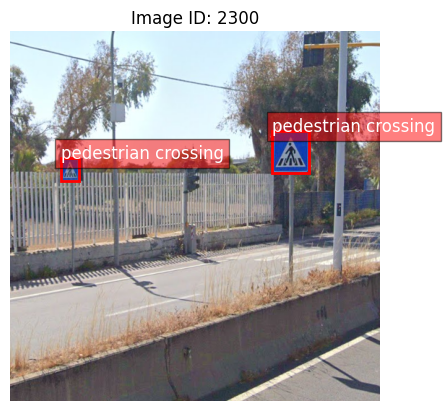

In [4]:
#image with bboxes plotting function

def plot_image_with_bboxes(image_filename, bboxes_df, dataset_path, markers = []):
    image = Image.open(os.path.join(dataset_path, "images", image_filename))
    image_id = int(image_filename.split(".")[0])

    #get bounding box information for the image
    bboxs = bboxes_df[bboxes_df['id'] == image_id]

    print("labels:", bboxs)

    #plot
    plt.axis('off')
    plt.title(f"Image ID: {image_id}")


    width, height = image.size

    for index, row in bboxs.iterrows():
        #the format is xyxy, convert to x,y,w,h first
        
        
        x1, y1, x2, y2 = row["xmin"] * width, row["ymin"] * height, row["xmax"] * width, row["ymax"] * height
        
        x = x1
        y = y1
        w = x2 - x1
        h = y2 - y1

        #plot the bounding box
        plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2))

        #plot the label
        plt.text(x, y, row["name"], fontsize=12, color='white', bbox=dict(facecolor='red', alpha=0.5))



        plt.imshow(image)
        plt.axis('off')
        plt.title(f"Image ID: {image_id}")

    for x,y in markers:
        plt.plot(x * width, y * height, 'wo', markersize=10) 
        plt.plot(x * width, y * height, 'gx', markersize=8) 


    plt.show()

image_filename = random.choice(os.listdir(os.path.join(dataset_path, "images")))
plot_image_with_bboxes(image_filename, bboxes_df, dataset_path)

# Question 1: Is it possible to summarize the bounding box coordinates with a multimodal distribution? Are there outliers?

In [5]:
#%matplotlib qt

### Scatter plot of centers

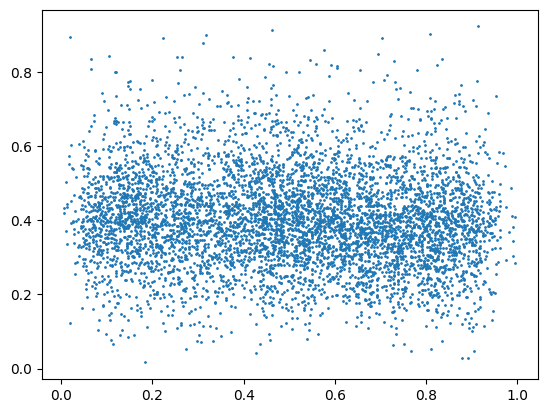

'\n#3d plot of center_x, center_y and diagonal\nfig = plt.figure()\nax = fig.add_subplot(111, projection=\'3d\')\nax.scatter(bboxes_df["center_x"], bboxes_df["center_y"], bboxes_df["diagonal"], s=1, cmap = "coolwarm")\nax.set_xlabel(\'X axis\')\nax.set_ylabel(\'Y axis\')\nax.set_zlabel(\'Diagonal\')\nplt.show()\n'

In [6]:
#calculate centers
bboxes_df["center_x"] = (bboxes_df["xmin"] + bboxes_df["xmax"]) / 2
bboxes_df["center_y"] = (bboxes_df["ymin"] + bboxes_df["ymax"]) / 2
bboxes_df["diagonal"] = (((bboxes_df["xmax"] - bboxes_df["xmin"])**2 + (bboxes_df["ymax"] - bboxes_df["ymin"])**2)**0.5)/(2**0.5)


plt.scatter(bboxes_df["center_x"], bboxes_df["center_y"], s=1, cmap = "coolwarm")
plt.show()

"""
#3d plot of center_x, center_y and diagonal
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(bboxes_df["center_x"], bboxes_df["center_y"], bboxes_df["diagonal"], s=1, cmap = "coolwarm")
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Diagonal')
plt.show()
"""


In [7]:
points = bboxes_df[["center_x", "center_y"]].values

#generate a permutation of the indices of the points
indices = numpy.arange(points.shape[0])
indices = numpy.random.permutation(indices)

points_fit = points[indices[:int(points.shape[0] * 0.8)]]
points_test = points[indices[int(points.shape[0] * 0.8):]]



print("points shape:", points.shape)

if numpy.any(numpy.isnan(points)):
    raise ValueError("There are NaN values in the data")
if numpy.any(numpy.isinf(points)):
    raise ValueError("There are infinite values in the data")

points shape: (5919, 2)


## Fitting a multivariate normal distribution to the data

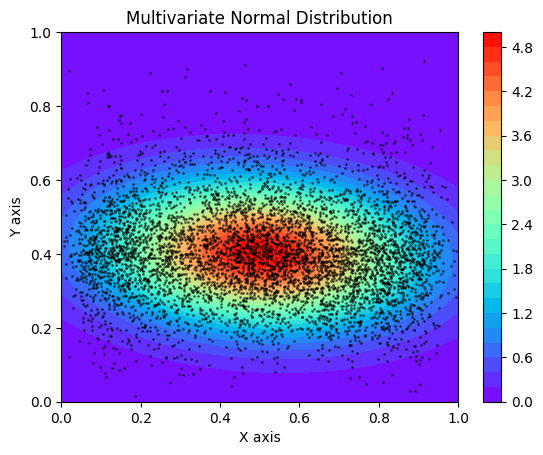

Mean log likelihood of test points (Multivariate Gaussian): 0.6060550938319851
BIC (Multivariate Gaussian): -1399.755193116921


In [8]:
from scipy.stats import multivariate_normal
import numpy as np
import matplotlib.pyplot as plt

# Fit manually
mean = np.mean(points_fit, axis=0)
cov = np.cov(points_fit.T)

# Create a multivariate normal distribution
rv = multivariate_normal(mean=mean, cov=cov)

# Plot
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)
X, Y = np.meshgrid(x, y)
Z = np.zeros(X.shape)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = rv.pdf([X[i, j], Y[i, j]])

plt.contourf(X, Y, Z, levels=30, cmap='rainbow')
plt.colorbar()
plt.scatter(points[:, 0], points[:, 1], s=1, c='black', cmap='coolwarm', alpha=0.5)
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.title('Multivariate Normal Distribution')
plt.show()

#log likelihood of the test points
log_likelihoods = rv.logpdf(points_test)
mean_log_likelihood = log_likelihoods.mean()

#number of data points
n = points_test.shape[0]

#number of parameters:
k = 2 + 3

#BIC 
log_likelihood_total = log_likelihoods.sum()
BIC = -2 * log_likelihood_total + k * np.log(n)

print("Mean log likelihood of test points (Multivariate Gaussian):", mean_log_likelihood)
print("BIC (Multivariate Gaussian):", BIC)


## Fitting a Gaussian Mixture Model to the data

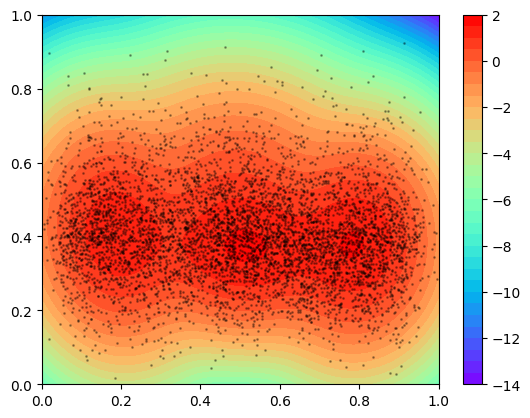

Log likelihood of test points: 0.7053259627953656
BIC of test points: -1507.448842144215


In [9]:
gmm = GaussianMixture(n_components=4, covariance_type='full').fit(points_fit) #covariance_type='full' is the default, other options are 'tied', 'diag', 'spherical'

#predict the labels
bboxes_df["gmm_labels"] = gmm.predict(points)


#x = numpy.linspace(bboxes_df["center_x"].min(), bboxes_df["center_x"].max(), 100)
#y = numpy.linspace(bboxes_df["center_y"].min(), bboxes_df["center_y"].max(), 100)

x = numpy.linspace(0, 1, 100)
y = numpy.linspace(0, 1, 100)


X, Y = numpy.meshgrid(x, y)
Z = numpy.zeros(X.shape)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = gmm.score(numpy.array([[X[i, j], Y[i, j]]]))

        


#Z = (Z - Z.min()) / (Z.max() - Z.min())
#Z = Z / Z.sum()

plt.contourf(X, Y, Z, levels=30, cmap = "rainbow", alpha=1)
plt.colorbar()

#plot the data
plt.scatter(points[:, 0], points[:, 1], c ="black", s=1, alpha=0.3, label="Fit points")




plt.show()

    
log_likelihood = gmm.score(points_test)
print("Log likelihood of test points:", log_likelihood)

#calculate the BIC
bic = gmm.bic(points_test)
print("BIC of test points:", bic)

## Considerations
### The GMM fit produces a higher log-likelihood than the multivariate normal distribution for the test points, suggesting that the data is better represented by a mixture of Gaussians, rather than a single Gaussian. However, models with more parameters tend to produce higher log-likelihoods values. For this reason, we also take into account the BIC score, which penalizes the log-likelihood based on the number of parameters. Once again, the results suggest that the data is better represented by a mixture of Gaussians, since its BIC score is lower than the one of the multivariate normal distribution.

## We can now check, using the probability score, what are the most common samples and what are the outliers, according to this fit.

--------- OUTLIERS ---------
probability: 0.00022620658865481782
labels:        id                     name      xmin      ymin      xmax      ymax  \
5140  619              no stopping  0.314453  0.380859  0.435547  0.505859   
5141  619  one-way traffic (right)  0.751953  0.681641  0.992188  0.748047   
5142  619  one-way traffic (right)  0.826172  0.884766  1.000000  0.960938   

      center_x  center_y  diagonal  gmm_labels      gmm_prob  
5140  0.375000  0.443359  0.123062           3  1.701967e-04  
5141  0.872070  0.714844  0.176242           1  4.618574e-06  
5142  0.913086  0.922852  0.134198           1  6.906030e-09  


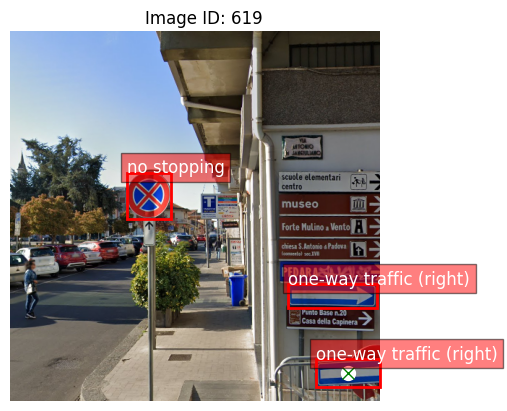

probability: 0.00022824097275161078
labels:         id        name      xmin      ymin      xmax      ymax  center_x  \
2681  2330  keep right  0.001953  0.853516  0.037109  0.937500  0.019531   
2682  2330    no entry  0.115234  0.599609  0.162109  0.656250  0.138672   
2683  2330    no entry  0.886719  0.601562  0.943359  0.654297  0.915039   

      center_y  diagonal  gmm_labels      gmm_prob  
2681  0.895508  0.064379           2  4.830743e-08  
2682  0.627930  0.051988           2  5.395612e-05  
2683  0.627930  0.054722           1  1.507312e-05  


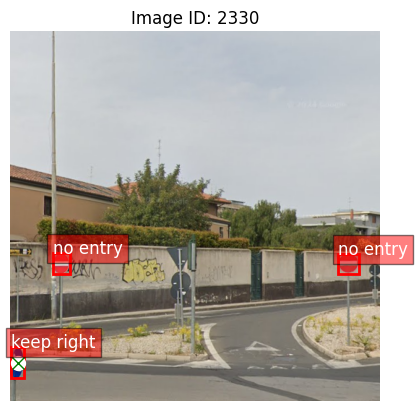

probability: 0.00019866914532653014
labels:         id      name      xmin      ymin      xmax      ymax  center_x  \
2177  2117  no entry  0.779297  0.847656  0.837891  0.957031  0.808594   

      center_y  diagonal  gmm_labels      gmm_prob  
2177  0.902344  0.087739           0  5.477651e-08  


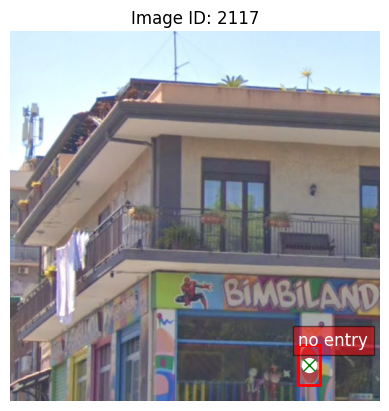

--------- INLIERS ---------
probability: 0.0002463647255521722
labels:         id        name      xmin      ymin      xmax      ymax  center_x  \
2937  2437  roundabout  0.447266  0.207031  0.583984  0.539062  0.515625   

      center_y  diagonal  gmm_labels  gmm_prob  
2937  0.373047  0.253906           3  0.000324  


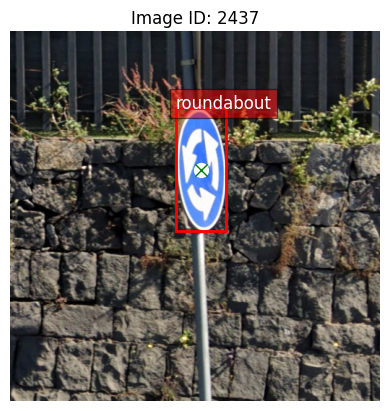

probability: 4.8887448195762006e-05
labels:         id                         name      xmin      ymin      xmax  \
1848  1963  drive straight or turn left  0.474609  0.455078  0.548828   
1849  1963                         stop  0.468750  0.294922  0.548828   

          ymax  center_x  center_y  diagonal  gmm_labels  gmm_prob  
1848  0.609375  0.511719  0.532227  0.121070           0  0.000145  
1849  0.453125  0.508789  0.374023  0.125381           3  0.000324  


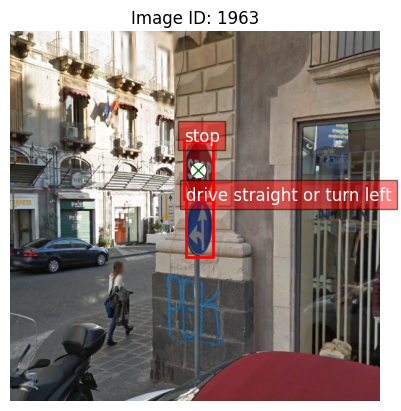

probability: 9.284653921193061e-05
labels:         id           name      xmin      ymin      xmax      ymax  center_x  \
1462  1751    no stopping  0.531250  0.210938  0.728516  0.431641  0.629883   
1463  1751  parking place  0.494141  0.359375  0.519531  0.386719  0.506836   

      center_y  diagonal  gmm_labels  gmm_prob  
1462  0.321289  0.209313           3  0.000218  
1463  0.373047  0.026385           3  0.000323  


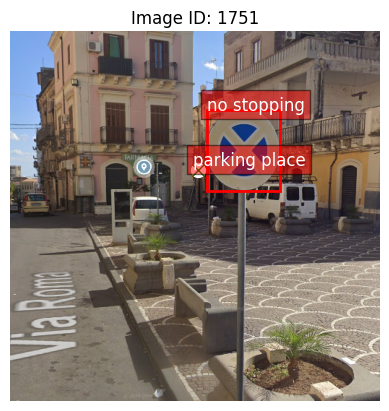

In [10]:
#plot outliers

probs = [gmm.score_samples(points[i].reshape(1, -1)) for i in range(points.shape[0])]
probs = numpy.exp(probs)
probs = probs / probs.sum()
probs = probs.reshape(-1, 1)

#add gmm probability column to bboxes_df
bboxes_df["gmm_prob"] = probs

#sort the bboxes_df by gmm_prob
bboxes_df_sorted = bboxes_df.sort_values(by="gmm_prob", ascending=False)



#plot the ith image calling the function plot_image_with_bboxes
print("--------- OUTLIERS ---------")
for i in range(-1, -4, -1): 
    print("probability:", bboxes_df.iloc[i]["gmm_prob"])

    image_id = bboxes_df_sorted.iloc[i]["id"]
    image_filename = str(image_id) + ".png"
    plot_image_with_bboxes(image_filename, bboxes_df, dataset_path, markers = [(bboxes_df_sorted.iloc[i]["center_x"], bboxes_df_sorted.iloc[i]["center_y"])])

print("--------- INLIERS ---------")

for i in range(3): 
    print("probability:", bboxes_df.iloc[i]["gmm_prob"])

    image_id = bboxes_df_sorted.iloc[i]["id"]
    image_filename = str(image_id) + ".png"
    plot_image_with_bboxes(image_filename, bboxes_df, dataset_path, markers = [(bboxes_df_sorted.iloc[i]["center_x"], bboxes_df_sorted.iloc[i]["center_y"])])





### As expected, outliers are located at the edges, while inliers tend to be found at the center of the image.

# Question 2: Do the samples of the two acquisitors follow similar distributions?

In [11]:
#join with metdatada to get acquirer
bboxes_df_acquirer = bboxes_df.merge(metadata_df[["id", "acquirer"]], on="id", how="left")

acquirer0_bboxes_df = bboxes_df_acquirer[bboxes_df_acquirer["acquirer"] == 0]
acquirer1_bboxes_df = bboxes_df_acquirer[bboxes_df_acquirer["acquirer"] == 1]

acquirer0_metadata_df = metadata_df[metadata_df["acquirer"] == 0]
acquirer1_metadata_df = metadata_df[metadata_df["acquirer"] == 1]


#sample len(acquisitor1_bboxes_df) points from acquisitor0_bboxes_df
acquirer0_bboxes_df = acquirer0_bboxes_df.sample(len(acquirer1_bboxes_df), random_state=47)
acquirer0_metadata_df = acquirer0_metadata_df.sample(len(acquirer1_metadata_df), random_state=47)

## Visual comparison

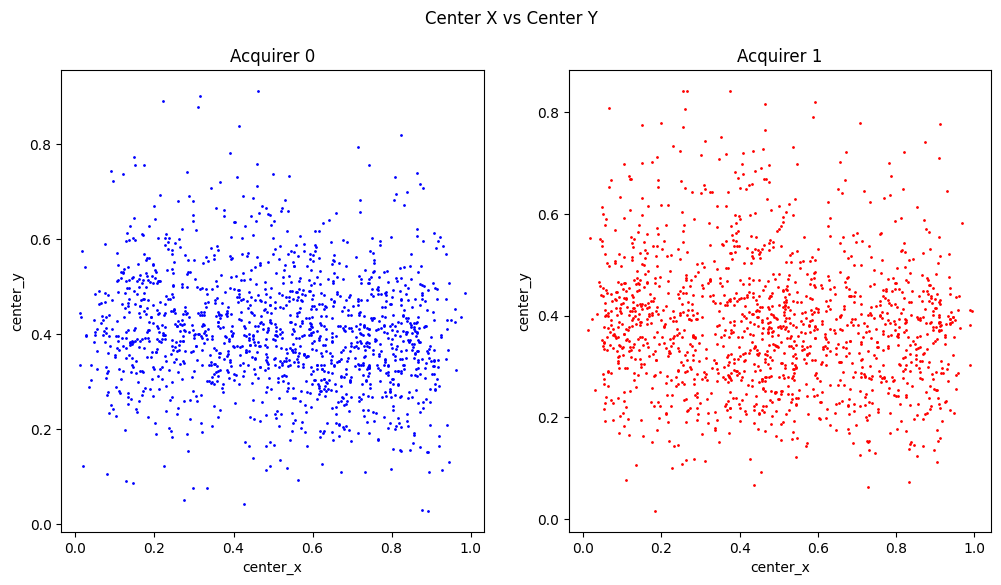

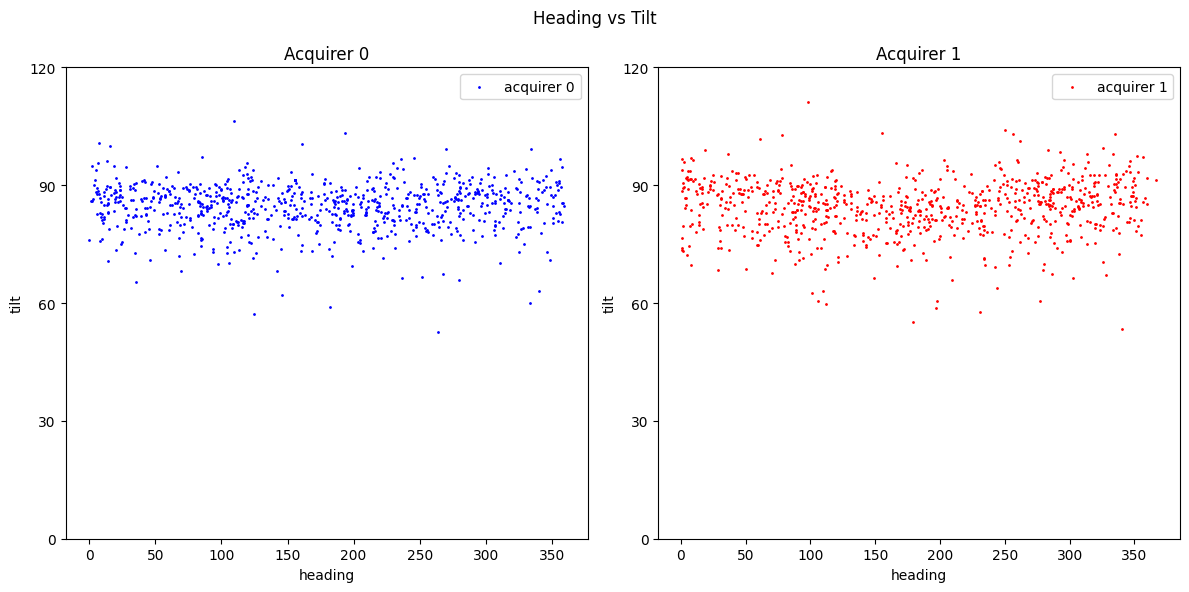

Text(0, 0.5, 'zoom')

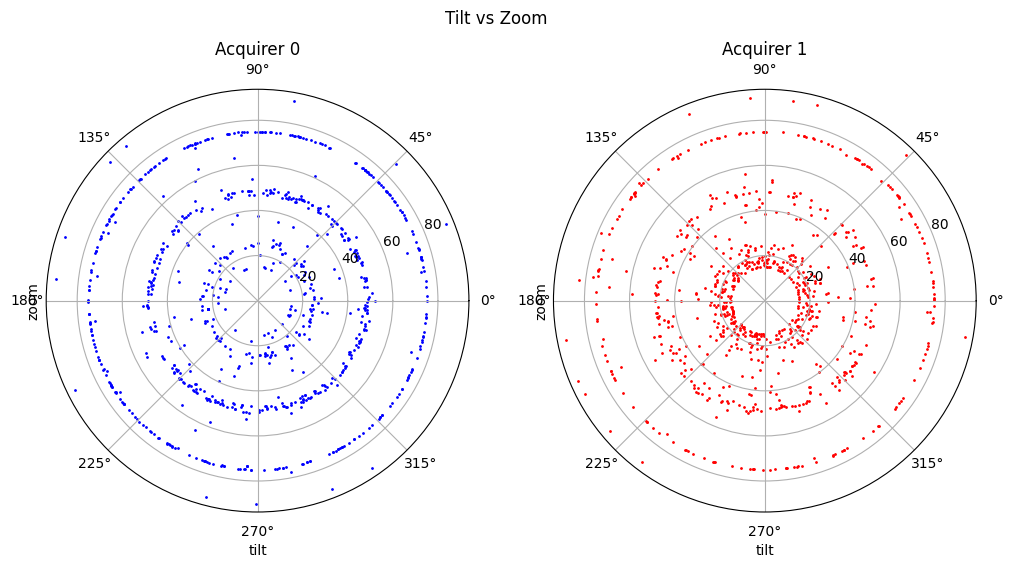

In [12]:
#some comparison plots

col1 = "center_x"
col2 = "center_y"

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Center X vs Center Y")
axs[0].scatter(acquirer0_bboxes_df[col1], acquirer0_bboxes_df[col2], s=1, c = "blue", label = "acquirer 0")
axs[0].set_title("Acquirer 0")
axs[0].set_xlabel(col1)
axs[0].set_ylabel(col2)

axs[1].scatter(acquirer1_bboxes_df[col1], acquirer1_bboxes_df[col2], s=1, c = "red", label = "acquirer 1")
axs[1].set_title("Acquirer 1")
axs[1].set_xlabel(col1)
axs[1].set_ylabel(col2)


col1 = "heading"
col2 = "tilt"

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Heading vs Tilt")
axs[0].scatter(acquirer0_metadata_df[col1]%360, acquirer0_metadata_df[col2], s=1, c = "blue", label = "acquirer 0")
axs[0].set_title("Acquirer 0")

#y ticks from 0 to 120
axs[0].set_yticks(numpy.arange(0, 121, 30))
axs[0].set_yticklabels(numpy.arange(0, 121, 30))

axs[0].set_xlabel(col1)
axs[0].set_ylabel(col2)
axs[0].legend()

axs[1].scatter(acquirer1_metadata_df[col1], acquirer1_metadata_df[col2], s=1, c = "red", label = "acquirer 1")
axs[1].set_title("Acquirer 1")

#y ticks from 0 to 120
axs[1].set_yticks(numpy.arange(0, 121, 30))
axs[1].set_yticklabels(numpy.arange(0, 121, 30))

axs[1].set_xlabel(col1)
axs[1].set_ylabel(col2)
axs[1].legend()


plt.tight_layout()
plt.show()

col1 = "tilt"
col2 = "zoom"

#polar coordinates plot (col1 as angle, col2 as radius)
fig, axs = plt.subplots(1, 2, figsize=(12, 6), subplot_kw=dict(polar=True))
fig.suptitle("Tilt vs Zoom")
axs[0].scatter(acquirer0_metadata_df[col1], acquirer0_metadata_df[col2], s=1, c = "blue", label = "acquirer 0")
axs[0].set_title("Acquirer 0")
axs[0].set_xlabel(col1)
axs[0].set_ylabel(col2)


axs[1].scatter(acquirer1_metadata_df[col1], acquirer1_metadata_df[col2], s=1, c = "red", label = "acquirer 1")
axs[1].set_title("Acquirer 1")
axs[1].set_xlabel(col1)
axs[1].set_ylabel(col2)




## We will now compare the following samples, divided by acquirer: 
 - heading and tilt
 - center_x and center_y 

## Energy test

### It is a statistical test that compares two samples to determine whether they are drawn from the same distribution. It is based on the energy distance, which is a measure of the difference between two probability distributions.
### The energy test is a non-parametric test, meaning that it does not make any assumptions about the underlying distributions of the data. It is particularly useful for comparing distributions that may not be normally distributed or have different shapes.

In [13]:
acquirer0_sample1 = acquirer0_metadata_df[[ "heading", "tilt"]]
acquirer1_sample1 = acquirer1_metadata_df[["heading", "tilt"]]

acquirer0_sample2 = acquirer0_bboxes_df[["center_x", "center_y"]]
acquirer1_sample2 = acquirer1_bboxes_df[["center_x", "center_y"]]

print("--- Energy test for heading and tilt ---")

# Convert to numpy arrays
X = acquirer0_sample1.to_numpy()
Y = acquirer1_sample1.to_numpy()

# Perform the test
stat, pvalue = Energy().test(X, Y)

print("Test statistic:", stat)
print("p-value:", pvalue)

# Interpret the result
if pvalue < 0.05:
    print("the distributions are different.")
else:
    print("the distributions may be the same.")


print("\n--- Energy test for center_x and center_y ---")

# Convert to numpy arrays
X = acquirer0_sample2.to_numpy()
Y = acquirer1_sample2.to_numpy()

# Perform the test
stat, pvalue = Energy().test(X, Y)

print("Test statistic:", stat)
print("p-value:", pvalue)

# Interpret the result
if pvalue < 0.05:
    print("the distributions are different.")
else:
    print("the distributions may be the same.")





--- Energy test for heading and tilt ---
Test statistic: 0.4280263584152024
p-value: 0.06795612642459821
the distributions may be the same.

--- Energy test for center_x and center_y ---
Test statistic: 0.00497221896841203
p-value: 2.0640418123876214e-06
the distributions are different.


## Testing distinguishability with a classifier network
### In order to further investigate the differences between the two distributions, we can train a classifier network to predict if a data point is from acquirer 1 or acquirer 2. We expect an accuracy value close to 0.5 if the two distributions are similar.

In [46]:
class AcquirerClassifier(pl.LightningModule):
    def __init__(self, input_dim = 2, output_dim = 1):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, 16)

        self.hidden1 = torch.nn.Linear(16, 16)
        self.hidden2 = torch.nn.Linear(16, 8)

        self.out = torch.nn.Linear(8, output_dim)
        self.relu = torch.nn.ReLU()

        self.loss_fn = torch.nn.BCEWithLogitsLoss()

    def forward(self, x):
        x = self.linear(x)
        x = self.relu(x)

        x = self.hidden1(x)
        x = self.relu(x)

        x = self.hidden2(x)
        x = self.relu(x)

        x = self.out(x)
        
        return x
        
    

    def compute_accuracy(self, y_hat, y):
        y_hat = torch.sigmoid(y_hat)
        y_hat = (y_hat > 0.5).float()
        acc = (y_hat == y).float().mean()
        return acc

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        loss = self.loss_fn(y_hat, y)

        acc = self.compute_accuracy(y_hat, y)
        
        self.log('train_loss', loss)
        self.log('train_acc', acc)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        loss = self.loss_fn(y_hat, y)

        acc = self.compute_accuracy(y_hat, y)
        
        self.log('val_loss', loss)
        self.log('val_acc', acc)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)
    


class AquirerDataset(Dataset):
    def __init__(self, df, train = True):
        self.df = df

        self.train = train

        self.len = int(len(df) * 0.8)

        if not train:
            self.len = len(df) - self.len

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        offset = 0 if self.train else len(self.df) - self.len

        x = self.df.iloc[idx + offset, :2].values.astype(float)
        y = self.df.iloc[idx + offset, 2].astype(float)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y

"""
acquirer0_sample1["acquirer"] = 0
acquirer1_sample1["acquirer"] = 1

acquirer0_sample2["acquirer"] = 0
acquirer1_sample2["acquirer"] = 1
"""

#use loc instead, to avoid warnings
acquirer0_sample1.loc[:, "acquirer"] = 0
acquirer1_sample1.loc[:, "acquirer"] = 1

acquirer0_sample2.loc[:, "acquirer"] = 0
acquirer1_sample2.loc[:, "acquirer"] = 1



sample1 = pd.concat([acquirer0_sample1, acquirer1_sample1], axis=0)
sample1 = sample1.reset_index(drop=True)
sample1 = sample1.sample(frac=1, random_state=47).reset_index(drop=True) #shuffle the dataframe

sample2 = pd.concat([acquirer0_sample2, acquirer1_sample2], axis=0)
sample2 = sample2.reset_index(drop=True)
sample2 = sample2.sample(frac=1, random_state=47).reset_index(drop=True) #shuffle the dataframe

#normalize the heading and tilt columns
sample1["heading"] = (sample1["heading"] - sample1["heading"].min()) / (sample1["heading"].max() - sample1["heading"].min())
sample1["tilt"] = (sample1["tilt"] - sample1["tilt"].min()) / (sample1["tilt"].max() - sample1["tilt"].min())

#normalize the center_x and center_y columns
sample2["center_x"] = (sample2["center_x"] - sample2["center_x"].min()) / (sample2["center_x"].max() - sample2["center_x"].min())
sample2["center_y"] = (sample2["center_y"] - sample2["center_y"].min()) / (sample2["center_y"].max() - sample2["center_y"].min())

sample2.head()


,center_x,center_y,acquirer
0,0.247515,0.920393,1
1,0.529821,0.392585,0
2,0.866799,0.673937,0
3,0.350895,0.390403,0
4,0.652087,0.494002,0


## Heading and tilt

In [15]:
TRAIN0 = False
BATCH_SIZE = 32

if TRAIN0:
    dataset_train = AquirerDataset(sample1, train=True)
    dataset_val = AquirerDataset(sample1, train=False)

    train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

    model = AcquirerClassifier(input_dim=2, output_dim=1)

    logger = TensorBoardLogger("logs", name="classifier_heading_vs_tilt")
    lr_monitor = LearningRateMonitor(logging_interval='step')
    progress_bar = RichProgressBar()

    trainer = Trainer(max_epochs=64, logger=logger, callbacks=[lr_monitor, progress_bar])
    trainer.fit(model, train_loader, val_loader)

    #save the model
    trainer.save_checkpoint("models/classifierr_heading_vs_tilt.ckpt")

## Center_x and center_y

In [16]:
if TRAIN0:
    dataset_train = AquirerDataset(sample2, train=True)
    dataset_val = AquirerDataset(sample2, train=False)

    train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

    model = AcquirerClassifier(input_dim=2, output_dim=1)

    logger = TensorBoardLogger("logs", name="classifier_cx_vs_cy")
    lr_monitor = LearningRateMonitor(logging_interval='step')
    progress_bar = RichProgressBar()

    trainer = Trainer(max_epochs=64, logger=logger, callbacks=[lr_monitor, progress_bar])
    trainer.fit(model, train_loader, val_loader)

    #save the model
    trainer.save_checkpoint("models/classifier_cx_vs_cy.ckpt")

# Training results
### The training curve of validation accuracy shows that the architecture performs better on the second dataset (center_x and center_y), while, for the first dataset (heading and tilt), the model reached an accuray of about 0.53, which is not significantly better than random guessing (0.5). 
### These results are consistent with the previous energy test.
<img src="./figs/val_acc1.png" width=262px height=290px />

### We may conclude that the two acquiers orient their camera in a similar way (that is reasonable, since it depends from the sign location), while their sign positions patterns are more distinguishable.

# Question 3: Is there a correlation between the bounding box size (diagonal) and the label?

## Filtering away least frequent labels

In [17]:
df = bboxes_df[["diagonal", "name"]]
#get only the entries with name "no entry", "no parking", "stop", "parking place"
df = df[df["name"].isin(["no entry", "no parking", "stop", "parking place", "no stopping", "pedestrian crossing", "give way", "roundabout", "turn right", "keep right", "turn left", "maximum speed 30km/h", "drive straight", "pass either side", "bumps in the road", "restricted vehicular access", "drive straight or turn right", "drive straight or turn left"])]
df = df.reset_index(drop=True)

#print unique names
print("unique names:", len(df["name"].unique()), len(["no entry", "no parking", "stop", "parking place", "no stopping", "pedestrian crossing", "give way", "roundabout", "turn right", "keep right", "turn left", "maximum speed 30km/h", "drive straight", "pass either side", "bumps in the road", "restricted vehicular access", "drive straight or turn right", "drive straight or turn left"]))

unique names: 18 18


## Chi2 Test
### the diagonal variable is not categorical, but it can be treated as such, by discretizing it.

Chi2 statistic: 380.63522693375546
p-value: 5.196998211711808e-39
The two variables are significantly related


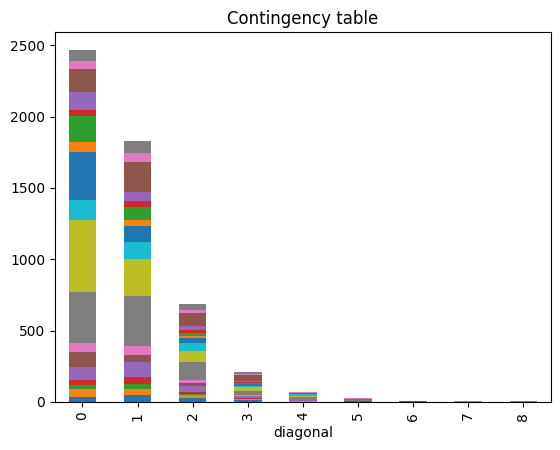

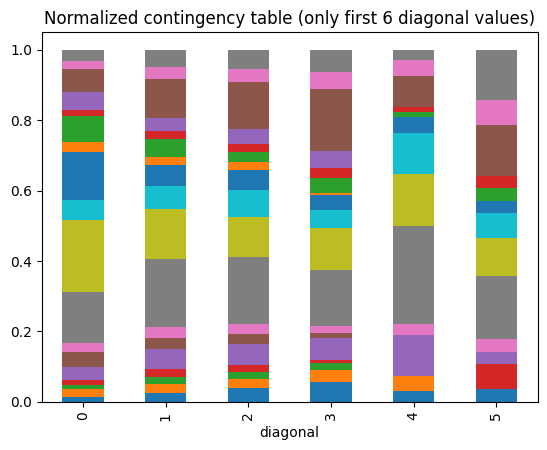

In [18]:
var1 = df["diagonal"]
var2 = df["name"]



#quantize data so it is categorical
var1 = pd.cut(var1, bins=9, labels=False)





contingency_table = pd.crosstab(var1, var2)

#plot the contingency table
contingency_table.plot(kind='bar', stacked=True)
plt.title("Contingency table")
#disable legend
plt.legend().set_visible(False)

#remove all the elements from var1 that are greater than 5
var1_r = var1[var1 <= 5]
contingency_table = pd.crosstab(var1_r, var2)




#plot normalized contingency table
contingency_table_normalized = contingency_table.div(contingency_table.sum(axis=1), axis=0)
contingency_table_normalized.plot(kind='bar', stacked=True)
plt.title("Normalized contingency table (only first 6 diagonal values)")
#disable legend
plt.legend().set_visible(False)


"""
#plot as heatmap, add a separation between the cells and hide heat values
plt.figure(figsize=(4, 6))
sns.heatmap(contingency_table.T, annot=False, fmt="d", cmap="YlGnBu", linewidths=.5, linecolor='black')
plt.title("Contingency table heatmap")
plt.xlabel(var1.name)
plt.ylabel(var2.name)
plt.show()
"""

#use the contingency table to calculate the chi2 statistic and p-value
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print("Chi2 statistic:", chi2_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("The two variables are significantly related")
else:
    print("The two variables are not significantly related")

## Test relation between continuous (diagonal) and categorical (label) variables with logistic regression

In [19]:
var1 = df["diagonal"]
var2 = df["name"]


print("var1 shape:", var1.shape)
print("var2 shape:", var2.shape)

#var2 contains strings, convert to indidices
var2 = pd.factorize(var2)[0]

#convert to dataframe column
var2 = pd.Series(var2, name="name")


#normalize var1 to [0, 1]
var1 = (var1 - var1.min()) / (var1.max() - var1.min())

#put in the same dataframe
df = pd.concat([var1, var2], axis=1)
df.head()

#fit the logit model
logit_model = mnlogit("name ~ diagonal", data=df).fit() 
logit_model.summary()


var1 shape: (5302,)
var2 shape: (5302,)
Optimization terminated successfully.
         Current function value: 2.581149
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:                   name   No. Observations:                 5302
Model:                        MNLogit   Df Residuals:                     5268
Method:                           MLE   Df Model:                           17
Date:                Mon, 28 Apr 2025   Pseudo R-squ.:                 0.01090
Time:                        03:57:21   Log-Likelihood:                -13685.
converged:                       True   LL-Null:                       -13836.
Covariance Type:            nonrobust   LLR p-value:                 5.068e-54
==============================================================================
    name=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4611      0.079     -5.801      0.000      -0.617      -0.305
diagonal       3.4357      0.469      7.327      0.000       2.517       4.355
------------------------------------------------------------------------------
    name=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.2791      0.155    -14.742      0.000      -2.582      -1.976
diagonal       2.8898      0.849      3.405      0.001       1.227       4.553
------------------------------------------------------------------------------
    name=3       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.3233      0.143    -16.195      0.000      -2.605      -2.042
diagonal       4.2692      0.722      5.915      0.000       2.855       5.684
------------------------------------------------------------------------------
    name=4       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9637      0.126    -15.619      0.000      -2.210      -1.717
diagonal       4.0526      0.654      6.193      0.000       2.770       5.335
------------------------------------------------------------------------------
    name=5       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2086      0.094    -12.854      0.000      -1.393      -1.024
diagonal       4.4581      0.511      8.716      0.000       3.456       5.461
------------------------------------------------------------------------------
    name=6       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2314      0.092     -2.506      0.012      -0.412      -0.050
diagonal      -3.1072      0.693     -4.485      0.000      -4.465      -1.749
------------------------------------------------------------------------------
    name=7       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9721      0.109     -8.891      0.000      -1.186      -0.758
diagonal      -0.6589      0.744     -0.886      0.376      -2.117       0.799
------------------------------------------------------------------------------
    name=8       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.7615      0.163    -16.949      0.000      -3.081      -2.442
diagonal       5.0668      0.759      6.673      0.000       3.579       6.555
------------------------------------------------------------------------------
  

## Considerations
### The predictor based on the diagonal variable has a statistically significant impact on many of the categories of name. The p-values for the "diagonal" variable in most cases are very low (< 0.05).
### There is enough evidence to conclude that there is a significant relationship between the diagonal size of the bounding boxes and the labels.
### This result is consistent with the previous chi2 test.

# Question 4: Is it possible to predict the label from the bounding box content histogram?

## Method: Softmax regressor

### It is a generalization of logistic regression used for multi-class classification problems. It models the probability that a given input belongs to each of the possible classes using the softmax function, which ensures that the output values are in the range [0, 1] and sum to 1. The model is trained by minimizing a cross-entropy loss function.

### To identify a good set of hyperparameters (such as regularization strength), we will use k-fold cross-validation, which allows us to assess model performance across multiple data splits, reducing the risk of overfitting and improving generalization.

### Finally, we will compare the results of a model trained with arbitrary hyperparameters with those of a model trained with the hyperparameters that maximized the average accuracy across the folds.

## Preparing the data: selecting only 4 classes (no parking, no stopping, parking place, turn (left/right)) & dataframe balancing

Lenght of dataframe before filtering: 5919
Lenght of dataframe before balancing: 2097


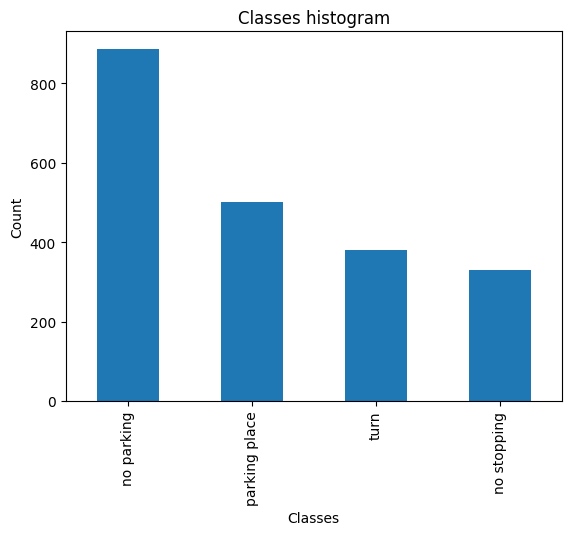

Min class: no stopping
Min class count: 330


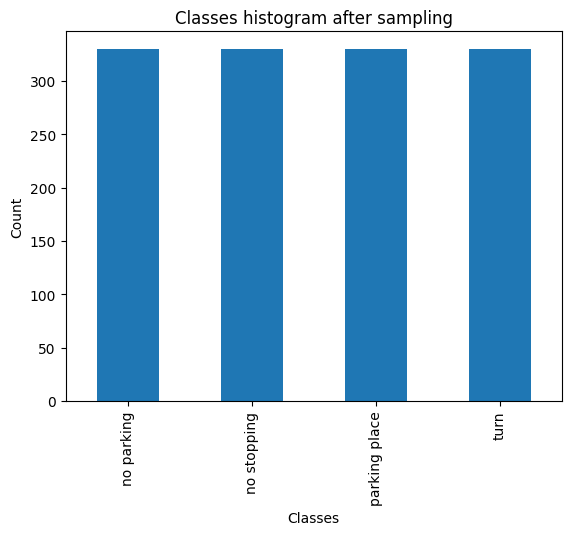

Length of dataframe: 1320


In [20]:
#select only the bboxes with classes "no entry", "no stopping", "parking place", "right turn"
print("Lenght of dataframe before filtering:", len(bboxes_df))
bboxes_reduced_df = bboxes_df[bboxes_df["name"].isin(["no parking", "no stopping", "parking place", "turn right", "turn left"])]

print("Lenght of dataframe before balancing:", len(bboxes_reduced_df))

#rename classes turn right and turn left to "turn"
#bboxes_reduced_df["name"] = bboxes_reduced_df["name"].replace({"turn right": "turn", "turn left": "turn"})

#do the rename with loc instead, to avoid warnings
bboxes_reduced_df.loc[:, "name"] = bboxes_reduced_df["name"].replace({"turn right": "turn", "turn left": "turn"})


#plot histogram of the classes
bboxes_reduced_df["name"].value_counts().plot(kind='bar')
plt.title("Classes histogram")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

#get the class with least samples, reduce the other classes to the same number of samples by random sampling
min_class = bboxes_reduced_df["name"].value_counts().idxmin()
min_class_count = bboxes_reduced_df["name"].value_counts().min()
print("Min class:", min_class)
print("Min class count:", min_class_count)

#sample the other classes to the same number of samples as the min class
bboxes_reduced_df = bboxes_reduced_df.groupby("name")
#select grouping colmumns
bboxes_reduced_df = bboxes_reduced_df[["id", "name", "xmin", "ymin", "xmax", "ymax", "center_x", "center_y", "diagonal"]].apply(lambda x: x.sample(min_class_count)).reset_index(drop=True)

#plot histogram of the classes
bboxes_reduced_df["name"].value_counts().plot(kind='bar')
plt.title("Classes histogram after sampling")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

#print len of dataframe 
print("Length of dataframe:", len(bboxes_reduced_df))

### Levels of quantizaition and utility function for histogram plotting

In [21]:
LEVELS = 4 # number of possible colors: LEVELS**3
def index_to_color(index):
    global LEVELS

    d = 256 // LEVELS
    r = index // (LEVELS * LEVELS)
    g = (index // LEVELS) % LEVELS
    b = index % LEVELS
    return (r * d /255, g * d / 255, b * d / 255)



## Example of color histogram on random images

image filename: 123.png
max value of red channel: (0, 192)
Number of unique colors in the image: 23


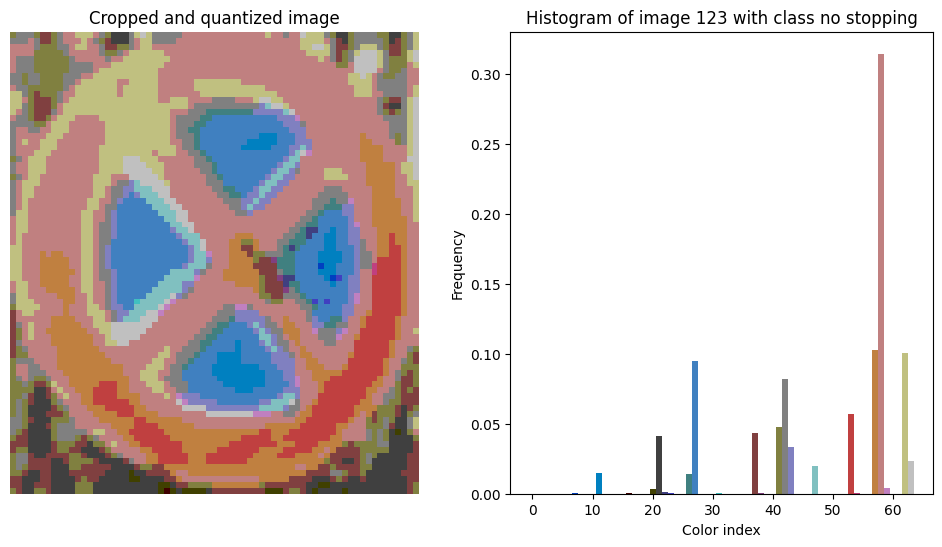

In [22]:
#test of histogram plot function



#open an image from dataset_path and quantize the 3 channels to 3 bits. Then plot the resulting image
image_filename = random.choice(os.listdir(os.path.join(dataset_path, "images")))       #337.png  #968
print("image filename:", image_filename)
image = Image.open(os.path.join(dataset_path, "images", image_filename))
image = image.convert("RGB")

#get bounding boxes with id = filename.split(".")[0]
image_id = int(image_filename.split(".")[0])

bboxes = bboxes_df[bboxes_df['id'] == image_id]


for index, row in bboxes.iterrows():
    #the format is xyxy, so convert to x,y,w,h first
    x1, y1, x2, y2 = row["xmin"] * image.size[0], row["ymin"] * image.size[1], row["xmax"] * image.size[0], row["ymax"] * image.size[1]
    
    #draw a rectangle on the image
    image_crop = Image.Image.crop(image, (x1, y1, x2, y2))

    image_red = image_crop.getchannel(0)
    image_green = image_crop.getchannel(1)
    image_blue = image_crop.getchannel(2)

    #quantize to 8 colors each
    #image_red = image_red.quantize(colors=4)
    #image_green = image_green.quantize(colors=4)
    #image_blue = image_blue.quantize(colors=4)

    #this quantization considers the min and max values of the image, so it is not uniform across the image, but we don't want that

    d = 256 // LEVELS #step
    #quantize the image to 4 colors (0, 1, 2, 3) for each channel
    image_red = image_red.point(lambda p: p // d * d)
    image_green = image_green.point(lambda p: p // d * d)
    image_blue = image_blue.point(lambda p: p // d * d)



    #print max value of red channel 
    print("max value of red channel:", image_red.getextrema())
    

    #create a 8 x 8 x 8 array to store the frequency of each color
    color_frequency = numpy.zeros((LEVELS, LEVELS, LEVELS))
    for i in range(image_crop.size[0]):
        for j in range(image_crop.size[1]):
            
            r = image_red.getpixel((i, j)) // d
            g = image_green.getpixel((i, j)) // d
            b = image_blue.getpixel((i, j)) // d
            


            #increment the frequency of the color
            color_frequency[r, g, b] += 1

    
    #flatten and cat row to dataframe
    color_frequency = color_frequency.flatten()
    color_frequency = color_frequency / color_frequency.sum()
    color_frequency = color_frequency.tolist()
    
    #new_row = [image_id, row["name"]] + color_frequency
    #histogram_df.loc[len(histogram_df)] = new_row

    #recombine the channels 
    image_q = Image.merge("RGB", (image_red.convert("L"), image_green.convert("L"), image_blue.convert("L")))
    #image_q.show()

    #print number of unique colors in the image
    print("Number of unique colors in the image:", len(set(image_q.getdata())))

    #plot the histogram, each bar should have the associated color, for example 0 is (0,0,0)



    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(image_q)
    axs[0].axis('off')
    axs[0].set_title("Cropped and quantized image")
    axs[1].bar(range(LEVELS**3), color_frequency, color = list(map(index_to_color, range(LEVELS**3))), width=1)
    axs[1].set_title("Histogram of image " + str(image_id) + " with class " + row["name"])
    axs[1].set_xlabel("Color index")
    axs[1].set_ylabel("Frequency")
    plt.show()

    


## Creating histogram dataframe for predictive analysis

In [23]:
if os.path.exists("histogram.csv"):
    histogram_df = pd.read_csv("histogram.csv")

    print("histogram.csv already exists, loading it")
else:

    #process the images, create and store the histogram dataframe

    histogram_df = pd.DataFrame(columns=["id", "name"] + [i for i in range(LEVELS**3)])


    def image_to_histogram(image_id):
        global dataset_path, bboxes_reduced_df, histogram_df, LEVELS

        image_filename = str(image_id) + ".png"
        image = Image.open(os.path.join(dataset_path, "images", image_filename))
        image = image.convert("RGB")
        
        bboxes = bboxes_reduced_df[bboxes_reduced_df['id'] == image_id]


        for index, row in bboxes.iterrows():
            #the format is xyxy, so convert to x,y,w,h first
            x1, y1, x2, y2 = row["xmin"] * image.size[0], row["ymin"] * image.size[1], row["xmax"] * image.size[0], row["ymax"] * image.size[1]
            
            #crop a rectangle from the image
            image_crop = Image.Image.crop(image, (x1, y1, x2, y2))

            image_red = image_crop.getchannel(0)
            image_green = image_crop.getchannel(1)
            image_blue = image_crop.getchannel(2)


            d = 256 // LEVELS #step

            #quantize
            image_red = image_red.point(lambda p: p // d * d)
            image_green = image_green.point(lambda p: p // d * d)
            image_blue = image_blue.point(lambda p: p // d * d)


            #count frequency of each color
            color_frequency = numpy.zeros((LEVELS, LEVELS, LEVELS))
            for i in range(image_crop.size[0]):
                for j in range(image_crop.size[1]):
                    
                    r = image_red.getpixel((i, j)) // d
                    g = image_green.getpixel((i, j)) // d
                    b = image_blue.getpixel((i, j)) // d
                    
                    color_frequency[r, g, b] += 1

            
            #flatten and cat row to dataframe
            color_frequency = color_frequency.flatten()
            #color_frequency = color_frequency / color_frequency.sum()

            color_frequency = color_frequency.astype(int)
            color_frequency = color_frequency.tolist()
            
            new_row = [image_id, row["name"]] + color_frequency
            histogram_df.loc[len(histogram_df)] = new_row

    cnt = 0
    for i in bboxes_reduced_df["id"].unique():
        image_to_histogram(i)
        
        if cnt % 100 == 0 or cnt == len(bboxes_reduced_df["id"].unique())- 1:
            print("Processed " + str(cnt) + "/" + str(len(bboxes_reduced_df["id"].unique())) + " images")

        cnt += 1
        

    #store in a csv file
    histogram_df.to_csv("histogram.csv", index=False)

print("number of rows in histogram_df:", len(histogram_df))
print("number of columns in histogram_df:", len(histogram_df.columns))


histogram.csv already exists, loading it
number of rows in histogram_df: 1320
number of columns in histogram_df: 66


## Normalizing data & converting labels to one-hot encoding

In [24]:
INDEX_TO_LABEL = ["no parking", "no stopping", "parking place", "turn"]


#to float
cols_to_convert = histogram_df.columns[2:]
histogram_df[cols_to_convert] = histogram_df[cols_to_convert].astype("float32")

#normalize the histogram to sum to 1
histogram_df.iloc[:, 2:] = histogram_df.iloc[:, 2:].div(histogram_df.iloc[:, 2:].sum(axis=1), axis=0)


#convert the labels to indices, using the INDEX_TO_LABEL list
histogram_df["name"] = histogram_df["name"].apply(lambda x: INDEX_TO_LABEL.index(x))

#create label1, label2, label3, label4 columns, after the second column
for i in range(4):
    histogram_df["label" + str(i)] =  (histogram_df["name"] == i).astype("float32")


#position the label columns after the second column
cols = histogram_df.columns.tolist()
cols.insert(2, cols.pop(cols.index("label0")))
cols.insert(3, cols.pop(cols.index("label1")))
cols.insert(4, cols.pop(cols.index("label2")))
cols.insert(5, cols.pop(cols.index("label3")))

#remove name column
#cols.remove("name")

histogram_df = histogram_df[cols]


#shuffle the dataframe with a certain seed (47)
histogram_df = histogram_df.sample(frac=1, random_state=47).reset_index(drop=True)


histogram_df.head()

,id,name,label0,label1,label2,label3,0,1,2,3,...,54,55,56,57,58,59,60,61,62,63
0,1185,2,0.0,0.0,1.0,0.0,0.0,0.005295,0.271739,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
1,1301,2,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.533333
2,2400,2,0.0,0.0,1.0,0.0,0.0,0.000000,0.001502,0.005255,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.217718
3,1946,2,0.0,0.0,1.0,0.0,0.0,0.170330,0.225275,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
4,1036,0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.004641,0.0,0.0,0.0,0.031156,0.016767,0.0,0.0,0.002031,0.086157


## Dataset class for training and testing

In [25]:
class HistogramDatasetTrainVal(Dataset):
    def __init__(self, histogram_df, train = True, split = 0.85, transform=None):
        self.data = histogram_df
        self.transform = transform
        self.train = train

        
        self.len = int(len(histogram_df) * split)
        if not self.train:
            self.len = len(histogram_df) - self.len

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        if self.train:
            x = self.data.iloc[idx, 6:].values
            y = self.data.iloc[idx, 2:6].values
            id = self.data.iloc[idx, 0]
        else:
            offset = len(self.data) - self.len
            x = self.data.iloc[idx + offset, 6:].values
            y = self.data.iloc[idx + offset, 2:6].values
            id = self.data.iloc[idx + offset, 0]
        
        if self.transform:
            x = self.transform(x)
            y = self.transform(y)

        #convert to float 32
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return id, x, y


## Training with 85-15 split
### The following procedure has been extecuted 2 times, once with the default hyperparameters and once with the hyperparameters found during cross-validation.

In [26]:
TRAIN1 = False

In [27]:
#dataloaders

train_dataset = HistogramDatasetTrainVal(histogram_df, train=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = HistogramDatasetTrainVal(histogram_df, train=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [28]:
"""
#get some data from train_loader and print it
for _, x, y in val_loader:
    print("id:", _)
    print("x shape:", x.shape)
    print("x:", x)
    print("y shape:", y.shape)
    print("y:", y)
    break
"""

'\n#get some data from train_loader and print it\nfor _, x, y in val_loader:\n    print("id:", _)\n    print("x shape:", x.shape)\n    print("x:", x)\n    print("y shape:", y.shape)\n    print("y:", y)\n    break\n'

In [29]:

class SoftmaxRegressor(torch.nn.Module):
    def __init__(self, input_size = LEVELS**3, output_size = 4):
        super(SoftmaxRegressor, self).__init__()
        self.linear = torch.nn.Linear(input_size, output_size)


    def forward(self, x):
        x = self.linear(x)

        return x
    



class HistogramClassifier(pl.LightningModule):
    def __init__(self, input_size = LEVELS**3, output_size = 4, learning_rate = 0.001, weight_decay = 0.0001):
        super(HistogramClassifier, self).__init__()
        self.model = SoftmaxRegressor(input_size, output_size)
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.loss_fn = torch.nn.CrossEntropyLoss()
        #self.accuracy = torch.nn.functional.binary_cross_entropy_with_logits


    def compute_accuracy(self, y_hat, y):
        preds = torch.argmax(y_hat, dim=1)
        targets = torch.argmax(y, dim=1)
        
        correct = (preds == targets).sum().item()
        total = targets.size(0)
        return correct / total
    

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay = self.weight_decay)


    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):
        _, x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        #acc = self.accuracy(y_hat, y)

        #acc = self.compute_accuracy(y_hat, y)

        self.log("train_loss", loss, prog_bar=True)
        #self.log("train_acc", acc, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        _, x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        #acc = self.accuracy(y_hat, y)

        acc = self.compute_accuracy(y_hat, y)


        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        #self.log("val_acc", acc, prog_bar=True)
        return loss

In [30]:
if TRAIN1:
    #set all the seeds to 47 (numpy torch etc)
    numpy.random.seed(47)
    random.seed(47) 
    torch.manual_seed(47)

    model = HistogramClassifier(input_size = LEVELS**3, output_size = 4, learning_rate = 0.01, weight_decay = 0.0001) #note: I executed train1 twice, the first time I used the default learning rate and weight decay, the second time I used 0.01 and 0.00001 (chosen with k-fold cross validation)

In [31]:
#train



if TRAIN1:
    logger = TensorBoardLogger("logs", name="histogram_classifier kf hyp", version=0)   #v0:128, v1: 256 v2 (for kf hyp version only):64,  for kr: v0: 128, v3                                          #split 80-20v0: 32, v1: 128, v2: 256
    #checkpoint_callback = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1, dirpath="checkpoints")
    #early_stopping_callback = EarlyStopping(monitor="val_acc", patience=5, mode="max")
    lr_monitor = LearningRateMonitor(logging_interval='step')
    progress_bar = RichProgressBar()

    #trainer = trainer = Trainer(accelerator = "gpu", devices = 1, max_epochs = 16, logger = logger, gradient_clip_val = 1, gradient_clip_algorithm = "norm", log_every_n_steps=1)

    trainer = Trainer(max_epochs=128, logger=logger, callbacks=[lr_monitor, progress_bar], log_every_n_steps=4, accelerator = "gpu", devices = 1, gradient_clip_val = 1, gradient_clip_algorithm = "norm")
    trainer.fit(model, train_loader, val_loader)
else:
    #load model from checkpoint
    model = HistogramClassifier.load_from_checkpoint("models/histogram_classifier 256 epochs lr0.001 wd0.0001.ckpt")



In [32]:
#save model
if TRAIN1:
    trainer.save_checkpoint("models/histogram_classifier 128 epochs lr0.01 wd0.0001.ckpt")

In [33]:
#execute the model on a random sample from validation set #1185

model.eval()

id, x, y = val_dataset.__getitem__(random.randint(0, len(val_dataset) - 1))
print("id:", id)

prediction = model(x)

#get max value and index of the prediction

prediction = prediction.detach().numpy()
prediction = numpy.argmax(prediction, axis=0)
prediction = INDEX_TO_LABEL[prediction]

ground_truth = y.detach().numpy()
ground_truth = numpy.argmax(ground_truth, axis=0)
ground_truth = INDEX_TO_LABEL[ground_truth]

print("prediction:", prediction)
print("ground truth:", ground_truth)

#plot image with id id
image_filename = str(id) + ".png"
image = Image.open(os.path.join(dataset_path, "images", image_filename))
image = image.convert("RGB")
image.show()

id: 460
prediction: no stopping
ground truth: no stopping


## Confusion matrix

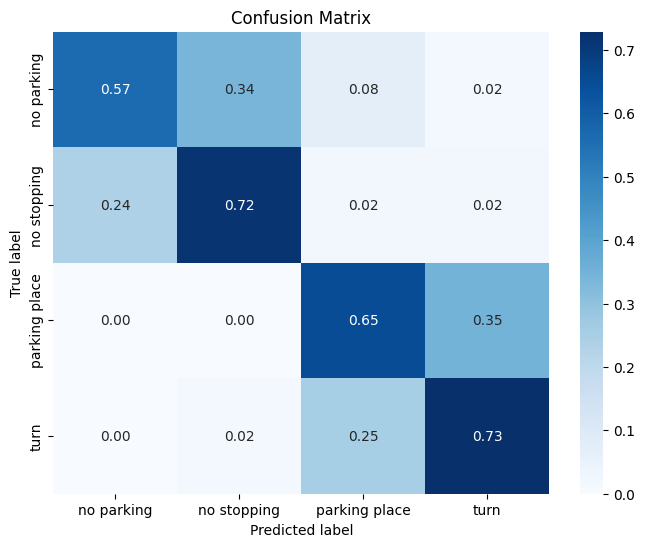

Accuracy: 0.6666666666666666
Precision: 0.6746539957038366
Recall: 0.6666666666666666
F1 Score: 0.6666435635475008


In [34]:
#confusion matrix plot function
def confusion_matrix_plot_and_stats(model, data_loader):
    model.eval()
    
    y_pred = []
    y_true = []

    for _, x, y in data_loader:
        y_hat = model(x)
        y_hat = y_hat.detach().numpy()

        y_ = y.detach().numpy()

        y_pred.append(y_hat)
        y_true.append(y_)

        
        

    y_pred = numpy.concatenate(y_pred, axis=0)
    y_true = numpy.concatenate(y_true, axis=0)
    y_pred = numpy.argmax(y_pred, axis=1)
    y_true = numpy.argmax(y_true, axis=1)

    #convert to labels
    y_pred = [INDEX_TO_LABEL[i] for i in y_pred]
    y_true = [INDEX_TO_LABEL[i] for i in y_true]

    #plot confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=INDEX_TO_LABEL)
    cm = cm.astype('float') / cm.sum(axis=1)[:, numpy.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=INDEX_TO_LABEL, yticklabels=INDEX_TO_LABEL)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Confusion Matrix')

    plt.show()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)


confusion_matrix_plot_and_stats(model, val_loader)

## Cross validation and hyperparameter choice
### The following procedure allows us to find the hyperparameters that maximize the average accuracy across the folds. The hyperparameters search is restricted to a small grid of values, in order to reduce the computational cost.

### The cross validation is executed in the first 85% of the dataset (last 15% is for testing)

In [35]:
del model, train_loader, val_loader #just in case

In [36]:
TRAIN2 = False

In [37]:
class HistogramDataset(Dataset):
    def __init__(self, histogram_df, transform=None):
        self.data = histogram_df
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data.iloc[idx, 6:].values
        y = self.data.iloc[idx, 2:6].values
        id = self.data.iloc[idx, 0]

        if self.transform:
            x = self.transform(x)
            y = self.transform(y)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return id, x, y

In [38]:
#get last 15% of the dataframe for testing
histogram_trainval_df = histogram_df.iloc[:int(len(histogram_df)*0.85)]
histogram_test_df = histogram_df.iloc[int(len(histogram_df)*0.85):]


LR_RANGE = [0.0001, 0.001, 0.01]
WD_RANGE = [0.00001, 0.0001, 0.001]

if TRAIN2:
    train_val_dataset = HistogramDataset(histogram_trainval_df)

    K = 4

    kf = KFold(n_splits=K, shuffle=False) #data is already shuffled




    #initialize a matrix to store average validation accuracy for each combination of hyperparameters
    average_loss_per_hyper_comb = numpy.zeros((len(LR_RANGE), len(WD_RANGE)))
    average_accuracy_per_hyper_comb = numpy.zeros((len(LR_RANGE), len(WD_RANGE)))




    for fold, ( train_index, val_index) in enumerate(kf.split(histogram_trainval_df)):
        print("Fold:", fold)
        print("---------------------------------------------")

        # train and val split
        train_subset = Subset(train_val_dataset, train_index)
        val_subset = Subset(train_val_dataset, val_index)

        # dataloaders
        train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

        for lr in LR_RANGE:
            for wd in WD_RANGE:
                print("Learning rate:", lr)
                print("Weight decay:", wd)

                model = HistogramClassifier(input_size = LEVELS**3, output_size = 4, learning_rate = lr, weight_decay = wd)


                logger = TensorBoardLogger("logs", name="histogram_classifier_kf", version= str(fold) + "_" + str(lr) + "_" + str(wd))
                lr_monitor = LearningRateMonitor(logging_interval='step')
                progress_bar = RichProgressBar()
                trainer = Trainer(max_epochs=64, logger=logger, callbacks=[lr_monitor, progress_bar], log_every_n_steps=4, accelerator = "gpu", devices = 1, gradient_clip_val = 1, gradient_clip_algorithm = "norm")
                trainer.fit(model, train_loader, val_loader)
                trainer.save_checkpoint(f"KF models/histogram_classifier_fold_{fold}_lr_{lr}_wd_{wd}.ckpt")

                #calculate val loss and add it to the matrix
                val_loss = trainer.callback_metrics["val_loss"].item()
                average_loss_per_hyper_comb[LR_RANGE.index(lr)][WD_RANGE.index(wd)] += val_loss / kf.n_splits

                #calculate val accuracy and add it to the matrix
                val_accuracy = trainer.callback_metrics["val_acc"].item()
                average_accuracy_per_hyper_comb[LR_RANGE.index(lr)][WD_RANGE.index(wd)] += val_accuracy / kf.n_splits

    #store val accuracy and loss in numpy files
    numpy.save("average_loss_per_hyper_comb.npy", average_loss_per_hyper_comb)
    numpy.save("average_accuracy_per_hyper_comb.npy", average_accuracy_per_hyper_comb)

In [39]:
if not TRAIN2:
    average_loss_per_hyper_comb = numpy.load("average_loss_per_hyper_comb.npy")
    average_accuracy_per_hyper_comb = numpy.load("average_accuracy_per_hyper_comb.npy")

In [40]:
#Choose the set of hyperparameters with the best accuracy, and the set with best loss
best_accuracy = numpy.unravel_index(numpy.argmax(average_accuracy_per_hyper_comb, axis=None), average_accuracy_per_hyper_comb.shape)
best_loss = numpy.unravel_index(numpy.argmin(average_loss_per_hyper_comb, axis=None), average_loss_per_hyper_comb.shape)

#map the indices to the hyperparameters values using the ranges
best_accuracy_lr = LR_RANGE[best_accuracy[0]]
best_accuracy_wd = WD_RANGE[best_accuracy[1]]

best_loss_lr = LR_RANGE[best_loss[0]]
best_loss_wd = WD_RANGE[best_loss[1]]

print("Best accuracy hyperparameters:")
print("Learning rate:", best_accuracy_lr)
print("Weight decay:", best_accuracy_wd)
print("Best accuracy:", average_accuracy_per_hyper_comb[best_accuracy[0]][best_accuracy[1]])

print("Best loss hyperparameters:")
print("Learning rate:", best_loss_lr)
print("Weight decay:", best_loss_wd)
print("Best loss:", average_loss_per_hyper_comb[best_loss[0]][best_loss[1]])

#save the hyperparameters in a txt
hyperparameters = {
    "best_accuracy_lr": best_accuracy_lr,
    "best_accuracy_wd": best_accuracy_wd,
    "best_loss_lr": best_loss_lr,
    "best_loss_wd": best_loss_wd
}

with open("hyperparameters.txt", "w") as f:
    f.write(str(hyperparameters))



Best accuracy hyperparameters:
Learning rate: 0.01
Weight decay: 0.0001
Best accuracy: 0.7023226916790009
Best loss hyperparameters:
Learning rate: 0.01
Weight decay: 1e-05
Best loss: 0.6904231160879135


## Comparing the two models
### model1 is trained with the default hyperparameters, while model2 is trained with the hyperparameters found during cross-validation.

--- Confusion matrix for model 1 (no kf tuning) ---


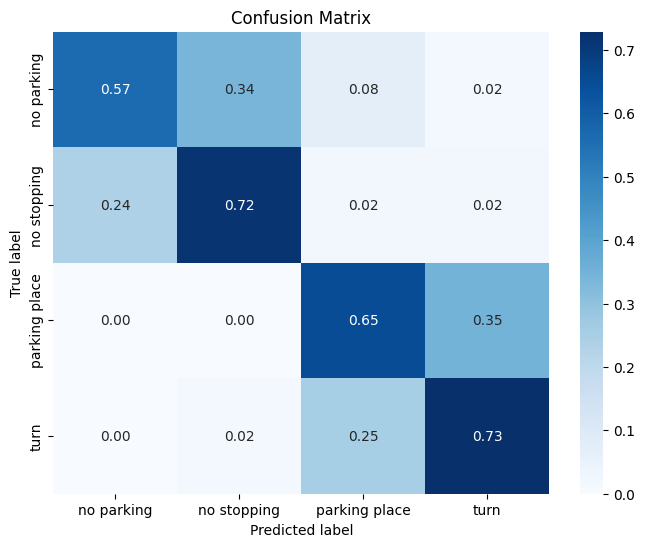

Accuracy: 0.6666666666666666
Precision: 0.6746539957038366
Recall: 0.6666666666666666
F1 Score: 0.6666435635475008

--- Confusion matrix for model 2 (kf tuning) ---


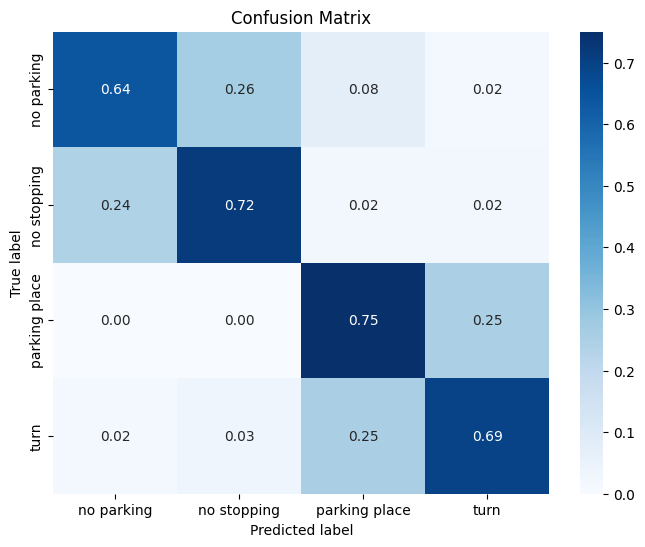

Accuracy: 0.696969696969697
Precision: 0.7060354258291677
Recall: 0.696969696969697
F1 Score: 0.6981062140352412


In [41]:
#compare best models obtained with and without k-fold cross validation hyperparameter tuning

test_dataset = HistogramDatasetTrainVal(histogram_df, train=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model1 = HistogramClassifier.load_from_checkpoint("models/histogram_classifier 256 epochs lr0.001 wd0.0001.ckpt") #no kf tuning
model2 = HistogramClassifier.load_from_checkpoint("models/histogram_classifier 128 epochs lr0.01 wd0.0001.ckpt") #kf tuning

#confusion matrix plot
print("--- Confusion matrix for model 1 (no kf tuning) ---")
confusion_matrix_plot_and_stats(model1, test_loader)
print("\n--- Confusion matrix for model 2 (kf tuning) ---")
confusion_matrix_plot_and_stats(model2, test_loader)

# Question 5: Is the model performance related to the acquisition location?

In [42]:
#do a join between histogram_df's id column and metadata_df to get latitude and longitude
histogram_df_id = histogram_df[["id"]]


histogram_coords_df = histogram_df.merge(metadata_df[["id", "latitude", "longitude"]], on="id", how="left")

#take only first 85% of the data (train data)
histogram_coords_df = histogram_coords_df.iloc[:int(len(histogram_coords_df)*0.85)]

histogram_coords_df.head()



,id,name,label0,label1,label2,label3,0,1,2,3,...,56,57,58,59,60,61,62,63,latitude,longitude
0,1185,2,0.0,0.0,1.0,0.0,0.0,0.005295,0.271739,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,37.603523,15.142192
1,1301,2,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.533333,37.598925,15.151767
2,2400,2,0.0,0.0,1.0,0.0,0.0,0.000000,0.001502,0.005255,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.217718,37.613966,15.026401
3,1946,2,0.0,0.0,1.0,0.0,0.0,0.170330,0.225275,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,37.506388,15.085678
4,1036,0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.031156,0.016767,0.0,0.0,0.002031,0.086157,37.588387,15.131421


## Latitude & longitude clustering with DBSCAN

Number of clusters: 7


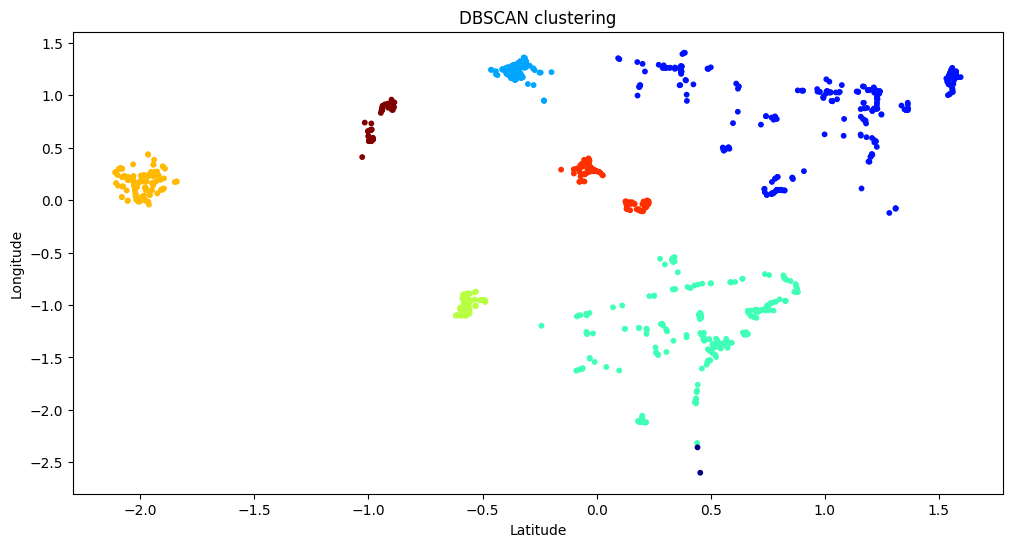

In [43]:
#using dbscan to cluster the data according to the latitude and longitude columns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import numpy as np

dbscan = DBSCAN(eps=0.3, min_samples=7)
#standardize the data
scaler = StandardScaler()
histogram_coords_df[["latitude", "longitude"]] = scaler.fit_transform(histogram_coords_df[["longitude", "latitude"]])

#fit the model
dbscan.fit(histogram_coords_df[["latitude", "longitude"]])
#add the labels to the dataframe
histogram_coords_df["dbscan_labels"] = dbscan.labels_

#plot the data with the labels
plt.figure(figsize=(12, 6))
plt.scatter(histogram_coords_df["latitude"], histogram_coords_df["longitude"], c=histogram_coords_df["dbscan_labels"], s=10, cmap="jet", alpha=1)
plt.title("DBSCAN clustering")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

#print number of clusters
n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
print("Number of clusters:", n_clusters)



## To dataframe

In [44]:
histogram_coords_df["prediction"] = 0
histogram_coords_df["correct"] = 0

for index, row in histogram_coords_df.iterrows():
    #convert to tensor
    x = torch.tensor(row[6:70].values, dtype=torch.float32)
    x = x.unsqueeze(0) #add batch dimension
    y_hat = model1(x)
    y_hat = y_hat.detach().numpy()
    y_hat = numpy.argmax(y_hat, axis=1)
    #y_hat = INDEX_TO_LABEL[y_hat[0]]
    histogram_coords_df.at[index, "prediction"] = y_hat

    if y_hat == row["name"]:
        histogram_coords_df.at[index, "correct"] = 1


#keep only id, dbscan_labels, correct
histogram_coords_df = histogram_coords_df[["id", "dbscan_labels", "correct"]]

#remove entries with dbscan_labels = -1
histogram_coords_df = histogram_coords_df[histogram_coords_df["dbscan_labels"] != -1]

histogram_coords_df.head()

,id,dbscan_labels,correct
0,1185,0,1
1,1301,0,1
2,2400,1,0
3,1946,2,1
4,1036,0,1


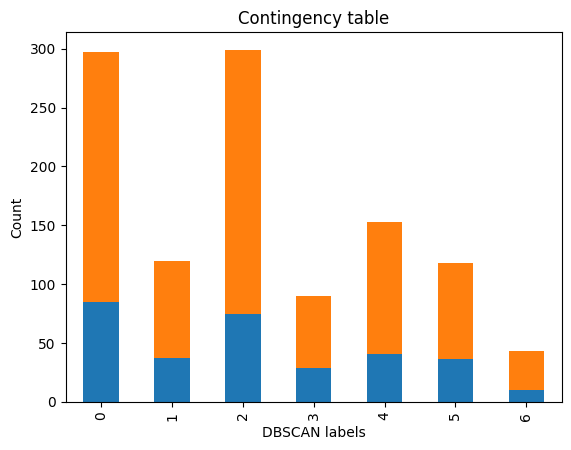

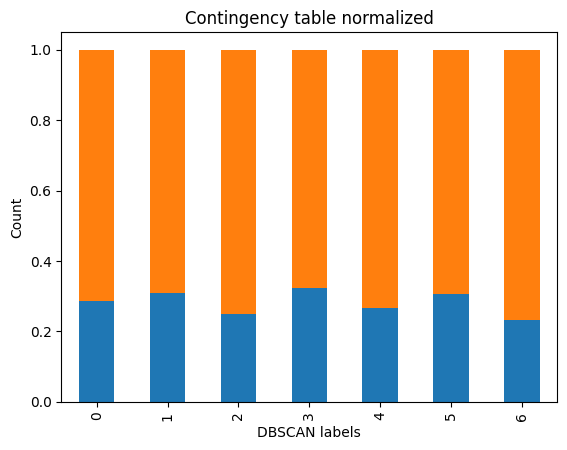

Chi2 statistic: 3.5523979351758905
p-value: 0.7369858329897574
The two variables are NOT significantly related


In [45]:
#run a statistical test to check if the correct and dbscan_labels are related. Since the data is categorical, we can use the chi2 test

contingency_table = pd.crosstab(histogram_coords_df["dbscan_labels"], histogram_coords_df["correct"])
#plot the contingency table
contingency_table.plot(kind='bar', stacked=True)
plt.title("Contingency table")
plt.xlabel("DBSCAN labels")
plt.ylabel("Count")
plt.legend().set_visible(False)
plt.show()

#do the same plot, but ormalize each bar to sum to 1
contingency_table_normalized = contingency_table.div(contingency_table.sum(axis=1), axis=0)
contingency_table_normalized.plot(kind='bar', stacked=True)
plt.title("Contingency table normalized")
plt.xlabel("DBSCAN labels")
plt.ylabel("Count")
plt.legend().set_visible(False)
plt.show()


#run test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print("Chi2 statistic:", chi2_stat)
print("p-value:", p_value)
if p_value < 0.05:
    print("The two variables are significantly related")

else:
    print("The two variables are NOT significantly related")

## Conclusions

### The analysis conducted throughout the project has provided meaningful insights into both the data distribution and the classification performance of the softmax regressor, on a simplified representation of the data. The use of k-fold cross-validation for hyperparameter optimization was effective and lead to a noticeable improvement in classification accuracy.ù

### Importantly, the results showed no significant correlation between the acquisition area and the correctness of the predictions, suggesting that the model generalizes well and is not overfitting to specific locations.
### <br>

### Finally, the answers to the initial statistical questions were successfully answered, consistently with the expectations: 
 - data distribution of bounding box positions were better described with a combination of multivariate Gaussians. Outliers were identified and explained.
 - label–bounding box size correlations were significant, indicating the presence of some bias in the data collection process
 - the data distributions of the two acquirers were compared, showing that they are similar for the heading and tilt variables, while they are more distinguishable for the center_x and center_y variables. This is consistent with the fact that the camera orientation is determined by the sign location, while the bounding box position is more dependent on the acquirer's behavior.

### Overall, the methodology provided a coherent and reliable analysis pipeline, both from a statistical and a machine learning perspective.